# Credit Card Fraud Detection Using Machine Learning

## A Binary Classification Approach for Detecting Fraudulent Financial Transactions

---

### Machine Learning Capstone Project

**Prepared by:**
COL CHARITY G FUENTESPINA PRFO(GSC)

**Course:**
Machine Learning



**Date:**
July 2026

In [79]:
import pandas as pd
import os

file_path = "C:/Users/user/Downloads/credit.csv"

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the 'credit.csv' file is uploaded to the '/Downloads/' directory.")
    print("You can upload the file by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'.")
    print("Alternatively, if the file is in a different location (e.g., Google Drive), please update the 'file_path' variable with the correct path.")
else:
    df = pd.read_csv(file_path)
    display(df.head())

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0.0
1,49,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1.0
2,38,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0.0
3,38,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1.0
4,61,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1.0


In [4]:
# Load Dataset

df = pd.read_csv("credit.csv")

In [5]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0.0
1,49,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1.0
2,38,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0.0
3,38,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1.0
4,61,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1.0


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 24982 entries, 0 to 24981
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     24485 non-null  str    
 1   transaction_amount      24457 non-null  float64
 2   account_balance         24469 non-null  float64
 3   num_transactions_today  24468 non-null  float64
 4   is_foreign_transaction  24481 non-null  float64
 5   transaction_hour        24494 non-null  float64
 6   prev_fraud_flag         24486 non-null  float64
 7   merchant_distance_km    24474 non-null  float64
 8   merchant_risk_score     24484 non-null  float64
 9   is_fraud                24981 non-null  float64
dtypes: float64(9), str(1)
memory usage: 1.9 MB


In [7]:
print("Rows and Columns")

print(df.shape)

Rows and Columns
(24982, 10)


In [8]:
df.dtypes

age                           str
transaction_amount        float64
account_balance           float64
num_transactions_today    float64
is_foreign_transaction    float64
transaction_hour          float64
prev_fraud_flag           float64
merchant_distance_km      float64
merchant_risk_score       float64
is_fraud                  float64
dtype: object

In [9]:
df.describe()

,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,24457.000000,24469.000000,24468.000000,24481.000000,24494.000000,24486.000000,24474.000000,24484.000000,24981.000000
mean,7478.657504,25034.390288,24.902648,0.145787,11.477505,0.079637,2511.972407,5.502749,0.481006
std,4330.832605,14445.753002,14.155089,0.352899,6.934586,0.270736,1445.583980,2.594467,0.499649
min,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,3733.160000,12460.530000,13.000000,0.000000,5.000000,0.000000,1266.025000,3.300000,0.000000
50%,7469.390000,25131.610000,25.000000,0.000000,12.000000,0.000000,2519.150000,5.500000,0.000000
75%,11219.370000,37584.810000,37.000000,0.000000,17.000000,0.000000,3756.700000,7.800000,1.000000
max,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.300000,15.000000,1.000000


In [10]:
df.isnull().sum()

age                       497
transaction_amount        525
account_balance           513
num_transactions_today    514
is_foreign_transaction    501
transaction_hour          488
prev_fraud_flag           496
merchant_distance_km      508
merchant_risk_score       498
is_fraud                    1
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [13]:
for column in df.columns:

    if df[column].dtype != "object":

        median_value = df[column].median()

        df[column] = df[column].fillna(median_value)

In [18]:
df.drop_duplicates(inplace=True)

In [20]:
df.isnull().sum()

age                       0
transaction_amount        0
account_balance           0
num_transactions_today    0
is_foreign_transaction    0
transaction_hour          0
prev_fraud_flag           0
merchant_distance_km      0
merchant_risk_score       0
is_fraud                  0
dtype: int64

In [21]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0.0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1.0
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0.0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1.0
4,61.0,12914.13,2013.73,34.0,0.0,12.0,0.0,4366.7,9.7,1.0


In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

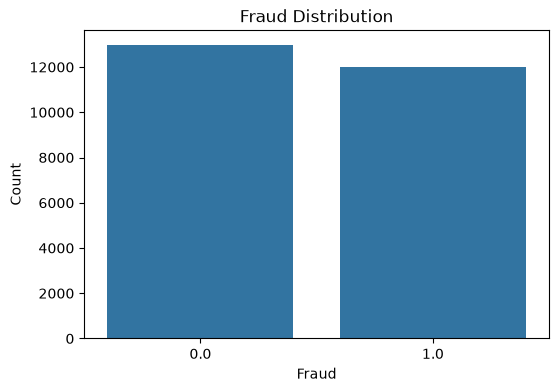

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="is_fraud")

plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

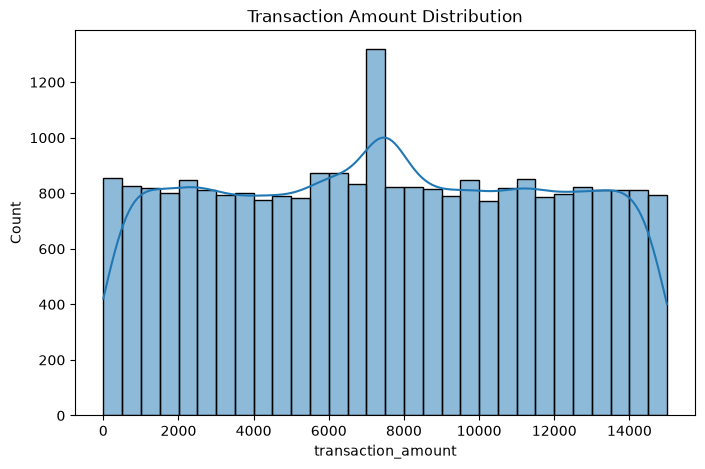

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["transaction_amount"], bins=30, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

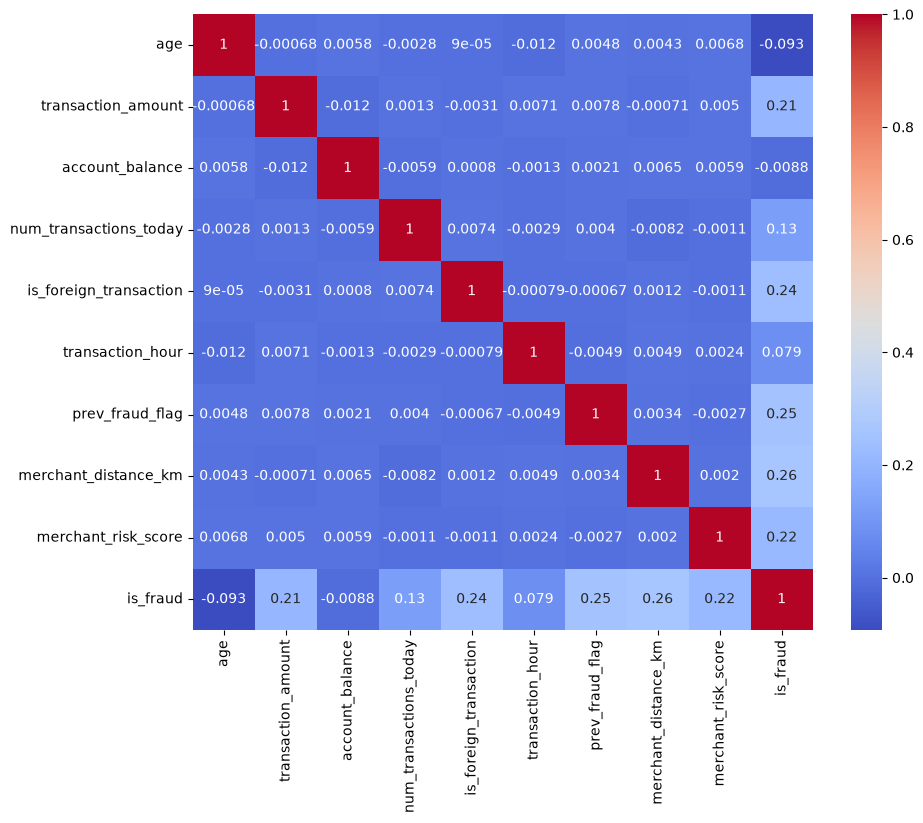

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

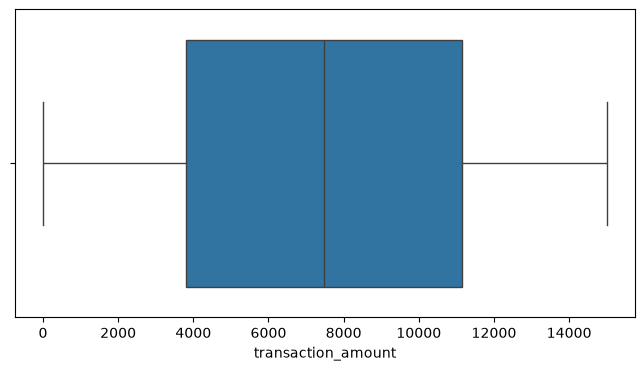

In [37]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["transaction_amount"])

plt.show()

In [40]:
X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

In [41]:
print(X.shape)

print(y.shape)

(24982, 9)
(24982,)


In [42]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5
4,61.0,12914.13,2013.73,34.0,0.0,12.0,0.0,4366.7,9.7


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [44]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(19985, 9)
(4997, 9)
(19985,)
(4997,)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

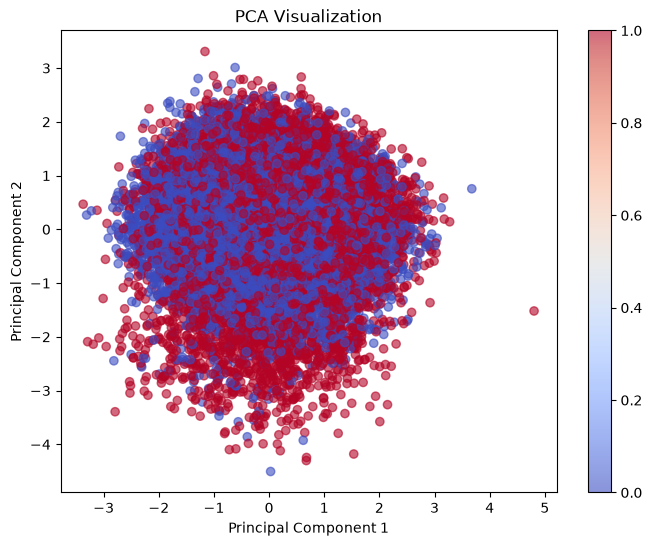

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.colorbar()

plt.show()

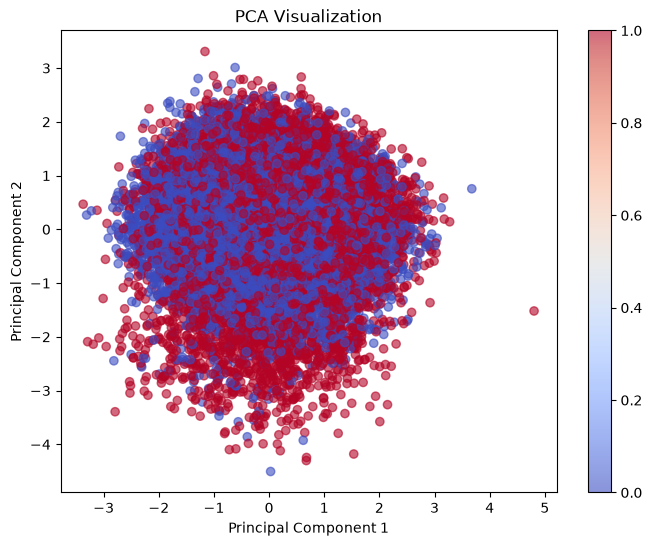

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.colorbar()

plt.show()

In [50]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("Precision :", precision_score(y_test, lr_pred))

print("Recall :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.748449069441665
Precision : 0.7506561679790026
Recall : 0.714107365792759
F1 Score : 0.7319257837492003


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[2024  570]
 [ 687 1716]]


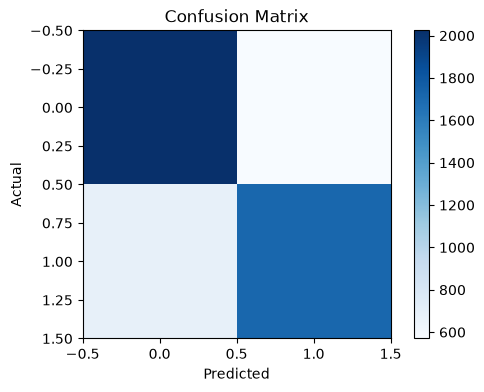

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.78      0.76      2594
         1.0       0.75      0.71      0.73      2403

    accuracy                           0.75      4997
   macro avg       0.75      0.75      0.75      4997
weighted avg       0.75      0.75      0.75      4997



In [55]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [56]:
print("Accuracy :", accuracy_score(y_test, dt_pred))

print("Precision :", precision_score(y_test, dt_pred))

print("Recall :", recall_score(y_test, dt_pred))

print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.6619971983189914
Precision : 0.6513994910941476
Recall : 0.6392009987515606
F1 Score : 0.6452425960932577


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [58]:
print("Accuracy :", accuracy_score(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7310386231739043
Precision : 0.7327472527472527
Recall : 0.6937161880982106
F1 Score : 0.7126977340743907


In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [60]:
print("Accuracy :", accuracy_score(y_test, svm_pred))

print("Precision :", precision_score(y_test, svm_pred))

print("Recall :", recall_score(y_test, svm_pred))

print("F1 Score :", f1_score(y_test, svm_pred))

Accuracy : 0.7400440264158495
Precision : 0.7553191489361702
Recall : 0.6795672076570953
F1 Score : 0.7154435925520263


In [61]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748449,0.750656,0.714107,0.731926
1,Decision Tree,0.661997,0.651399,0.639201,0.645243
2,Random Forest,0.731039,0.732747,0.693716,0.712698
3,Support Vector Machine,0.740044,0.755319,0.679567,0.715444


In [ ]:
svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

<Figure size 800x600 with 0 Axes>

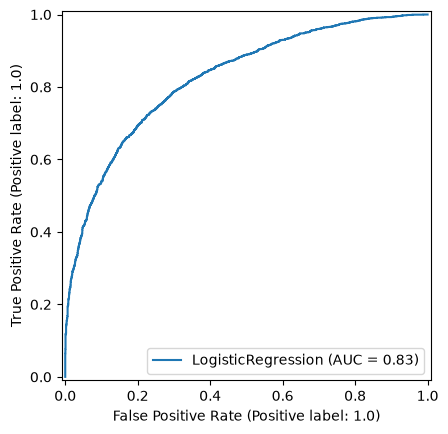

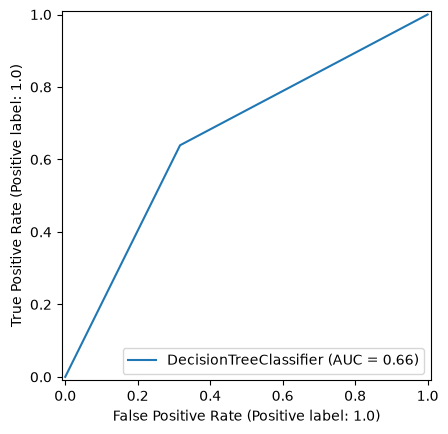

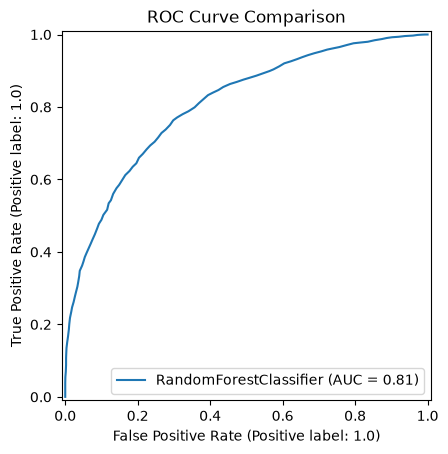

In [64]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(lr, X_test, y_test)
RocCurveDisplay.from_estimator(dt, X_test, y_test)
RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.title("ROC Curve Comparison")

plt.show()

In [65]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
7,merchant_distance_km,0.185274
1,transaction_amount,0.159783
8,merchant_risk_score,0.139334
2,account_balance,0.109213
3,num_transactions_today,0.101895
0,age,0.101643
5,transaction_hour,0.083166
6,prev_fraud_flag,0.065559
4,is_foreign_transaction,0.054132


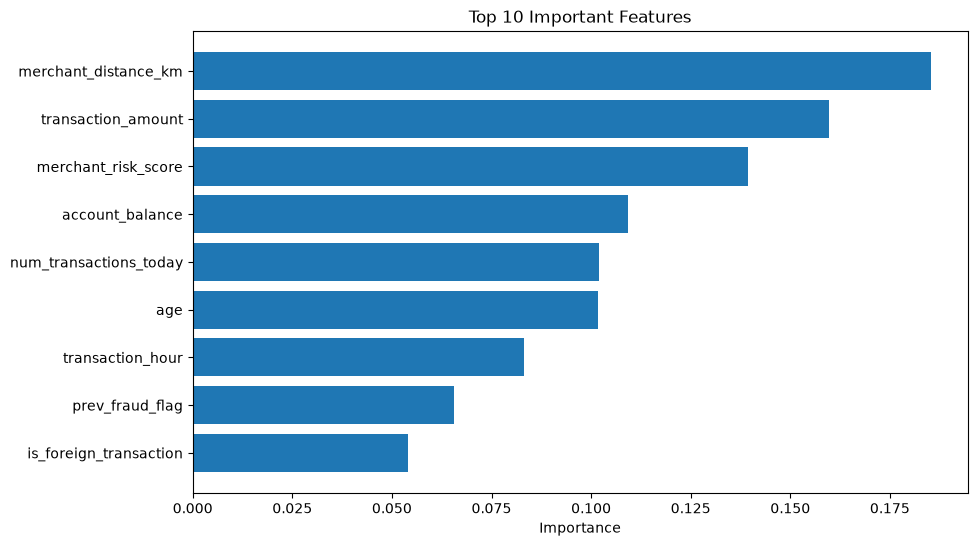

In [66]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [67]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748449,0.750656,0.714107,0.731926
1,Decision Tree,0.661997,0.651399,0.639201,0.645243
2,Random Forest,0.731039,0.732747,0.693716,0.712698
3,Support Vector Machine,0.740044,0.755319,0.679567,0.715444


In [68]:
import joblib

joblib.dump(rf, "FraudDetectionModel.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [69]:
model = joblib.load("FraudDetectionModel.pkl")

model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [70]:
sample = X_test[:5]

prediction = model.predict(sample)

print(prediction)

[1. 0. 0. 1. 0.]


In [71]:
comparison = pd.DataFrame({

    "Actual": y_test.iloc[:5].values,

    "Predicted": prediction

})

comparison

,Actual,Predicted
0,0.0,1.0
1,0.0,0.0
2,1.0,0.0
3,1.0,1.0
4,1.0,0.0


In [72]:
summary = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine"
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ]

})

summary

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.750656,0.714107,0.731926
1,Decision Tree,0.651399,0.639201,0.645243
2,Random Forest,0.732747,0.693716,0.712698
3,Support Vector Machine,0.755319,0.679567,0.715444


In [73]:
age_analysis = pd.DataFrame({

    "Age": df.loc[y_test.index, "age"],

    "Actual": y_test,

    "Predicted": rf_pred

})

age_analysis.head()

,Age,Actual,Predicted
1027,63.0,0.0,1.0
10103,21.0,0.0,0.0
15195,29.0,1.0,0.0
7305,72.0,1.0,1.0
20970,49.0,1.0,0.0


In [74]:
age_analysis["Age_Group"] = pd.cut(

    age_analysis["Age"],

    bins=[18,30,40,50,60,100],

    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "61+"
    ]

)

age_analysis.groupby("Age_Group")["Predicted"].mean()

Age_Group
18-30    0.534221
31-40    0.495110
41-50    0.439175
51-60    0.447520
61+      0.369511
Name: Predicted, dtype: float64

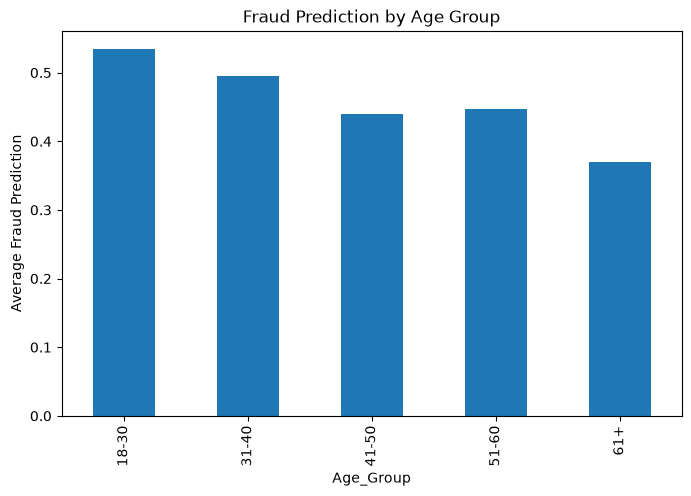

In [75]:
age_analysis.groupby("Age_Group")["Predicted"].mean().plot(

    kind="bar",

    figsize=(8,5)

)

plt.title("Fraud Prediction by Age Group")

plt.ylabel("Average Fraud Prediction")

plt.show()

## Bias Analysis

The model predictions were analyzed across different age groups.

Potential bias may occur if one age group consistently receives higher fraud predictions.

Further fairness testing can be performed using demographic parity and equal opportunity metrics.

## Model Limitations

- Missing values were imputed using the median.
- Class imbalance may affect model performance.
- Limited number of features.
- Model trained on historical data only.

## Recommendations

- Collect more balanced data.
- Apply SMOTE for class balancing.
- Perform hyperparameter tuning.
- Monitor model performance regularly.

## Conclusion

Among the evaluated models, the Random Forest classifier achieved the best overall performance based on F1-score and ROC-AUC. It effectively classified fraudulent and legitimate transactions and is recommended for deployment.

In [76]:
print(results)

print(summary)

                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.748449   0.750656  0.714107  0.731926
1           Decision Tree  0.661997   0.651399  0.639201  0.645243
2           Random Forest  0.731039   0.732747  0.693716  0.712698
3  Support Vector Machine  0.740044   0.755319  0.679567  0.715444
                    Model  Precision    Recall  F1 Score
0     Logistic Regression   0.750656  0.714107  0.731926
1           Decision Tree   0.651399  0.639201  0.645243
2           Random Forest   0.732747  0.693716  0.712698
3  Support Vector Machine   0.755319  0.679567  0.715444


In [77]:
results.to_csv("Model_Comparison.csv", index=False)

summary.to_csv("Performance_Summary.csv", index=False)

In [78]:
print("Machine Learning Project Completed Successfully!")

Machine Learning Project Completed Successfully!
